<a href="https://colab.research.google.com/github/markisabelle/Telco-Customer-Churn/blob/main/Notebook/Telco_Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
from google.colab import files
uploaded = files.upload()  # opens a file picker, choose your CSV
df = pd.read_csv("Telco-Customer-Churn.csv")

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn (2).csv


In [54]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [55]:
def check_data(dataframe, head=5):
  print(20*"-" + "Information".center(20) + 20*"-")
  print(dataframe.info())
  print(20*"-" + "Data Shape".center(20) + 20*"-")
  print(dataframe.shape)
  print("\n" + 20*"-" + "The First 5 Data".center(20) + 20*"-")
  print(dataframe.head())
  print("\n" + 20*"-" + "The Last 5 Data".center(20) + 20*"-")
  print(dataframe.tail())
  print("\n" + 20*"-" + "Missing Values".center(20) + 20*"-")
  print(dataframe.isnull().sum())
  print("\n" + 40*"-" + "Describe the Data".center(40) + 40*"-")
  print(dataframe.describe([0.01, 0.05, 0.1, 0.5, 0.75, 0.9, 0.95, 0.99]).T)\

check_data(df)

--------------------    Information     --------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-n

**Converting 'TotalCharges' from object to numeric**

In [56]:
pd.to_numeric(df.TotalCharges, errors='coerce').isna()
df.TotalCharges = pd.to_numeric(df.TotalCharges, errors='coerce')

df["TotalCharges"].dtypes

dtype('float64')

**Converting our target value (Churn) into a binary value for easier analysis**

In [57]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [58]:
df["Churn"] = df["Churn"].map({'No': 0, 'Yes': 1})

In [59]:
df['Churn'].dtypes

dtype('int64')

**Exploring Numerical Data**

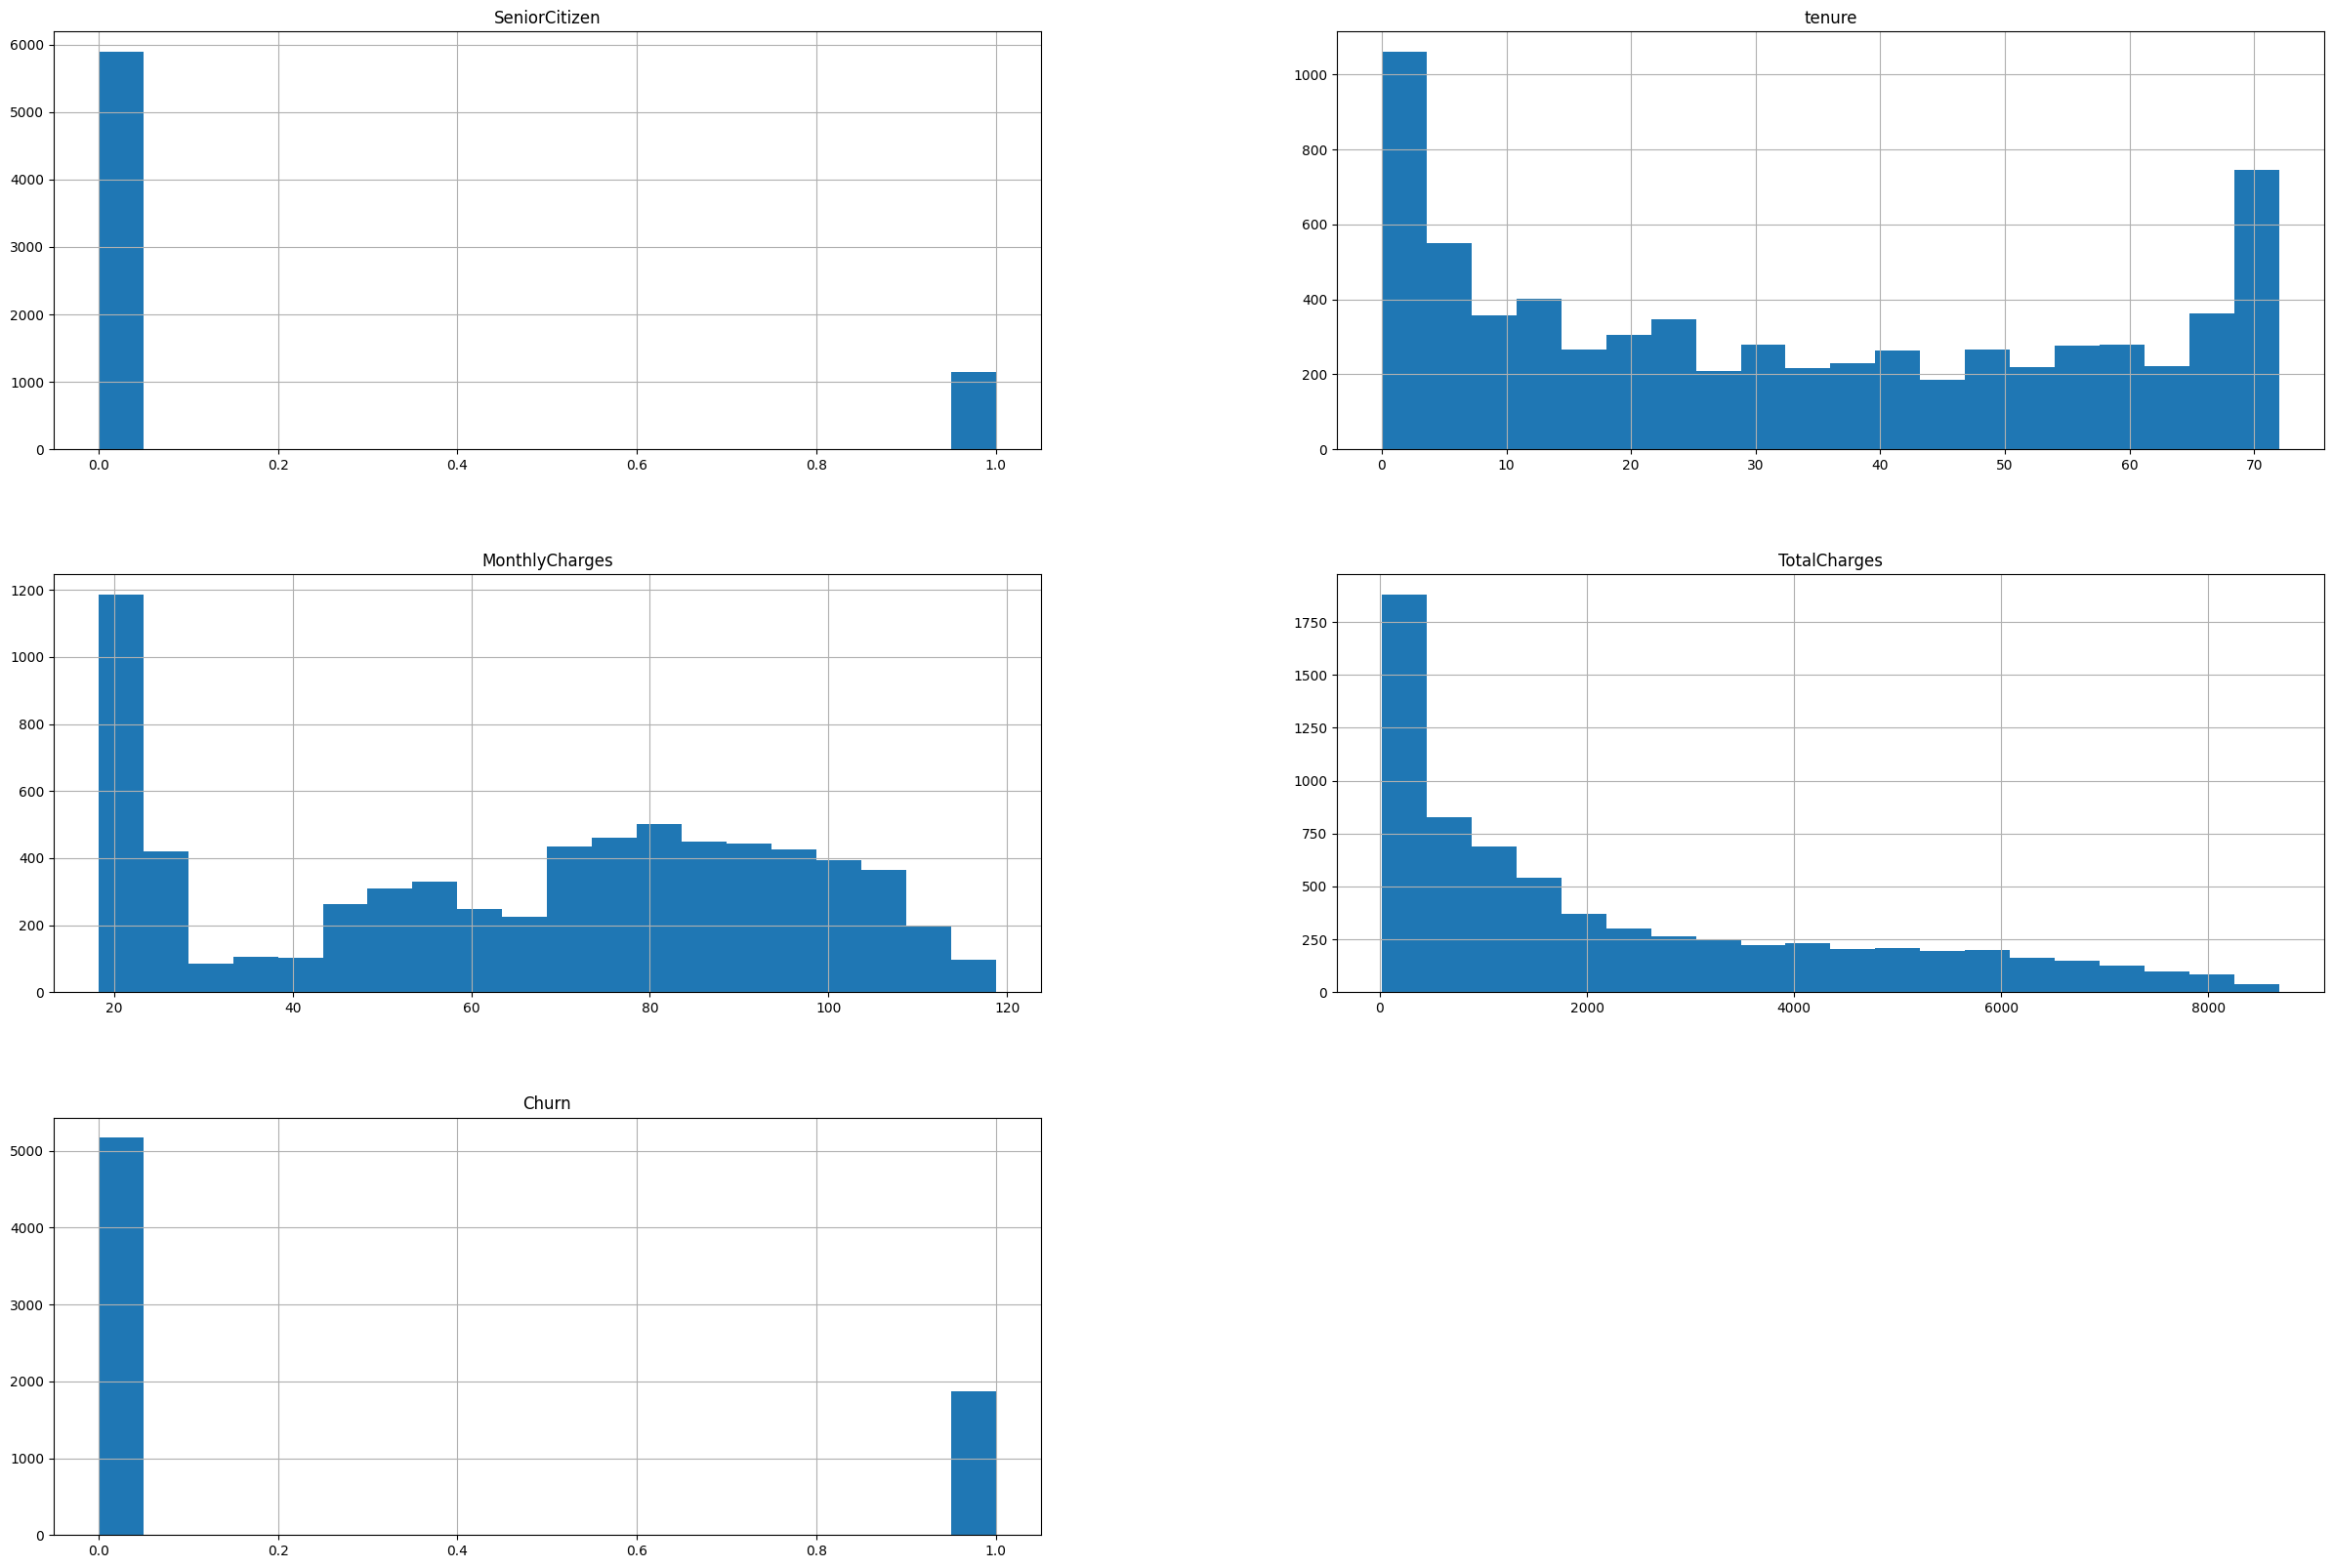

In [60]:
df.hist(bins=20, figsize=(30,20))
plt.savefig("churn_histogram")
plt.show()

**Finding column names that are Categorical, Numerical, Cardinality Categorical, and Numeric Categories**

In [61]:
def grab_col_names(dataframe, cat_th=10, card_th=20):

  # cat_cols, cat_but_car

  cat_cols = [
      col for col in dataframe.columns if dataframe[col].dtypes == "object"
  ]

  # Identify numerical columns that are actually categorical
  num_but_cat = [
      col for col in dataframe.columns if dataframe[col].nunique() < cat_th and dataframe[col].dtypes != "object"
  ]

  # Identify categorical columns that are cardinal (high unique values)
  cat_but_card = [
      col for col in dataframe.columns if dataframe[col].nunique() > card_th and dataframe[col].dtypes == "object"
  ]

  # Final list of categorical columns (excluding cardinal ones)
  cat_cols = cat_cols + num_but_cat
  cat_cols = [
      col for col in cat_cols if col not in cat_but_card
  ]


  # num_cols
  # Identify all numerical columns (not object type)
  num_cols = [
      col for col in dataframe.columns if dataframe[col].dtypes != "object"
  ]
  # Remove numerical columns that were classified as numerical-but-categorical
  num_cols = [
      col for col in num_cols if col not in num_but_cat
  ]


  print(f"Observations: {dataframe.shape[0]}")
  print(f"Variables: {dataframe.shape[1]}")
  print(f"categorey cols: {len(cat_cols)}")
  print(f"numerical cols: {len(num_cols)}")
  print(f"category but cardinal variable: {len(cat_but_card)}")
  print(f"numerical but categorical: {len(num_but_cat)}")

  return cat_cols, num_cols, cat_but_card, num_but_cat

In [62]:
cat_cols, num_cols, cat_but_card, num_but_cat = grab_col_names(df)

Observations: 7043
Variables: 21
categorey cols: 17
numerical cols: 3
category but cardinal variable: 1
numerical but categorical: 2


In [63]:
print(f"Category Columns: {cat_cols}")
print(f"Numerical Columns: {num_cols}")
print(f"Cardinality Category Columns: {cat_but_card}")
print(f"Numeric Category Columns: {num_but_cat}")

Category Columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen', 'Churn']
Numerical Columns: ['tenure', 'MonthlyCharges', 'TotalCharges']
Cardinality Category Columns: ['customerID']
Numeric Category Columns: ['SeniorCitizen', 'Churn']


**Analyzing the numerical and categorical variables**

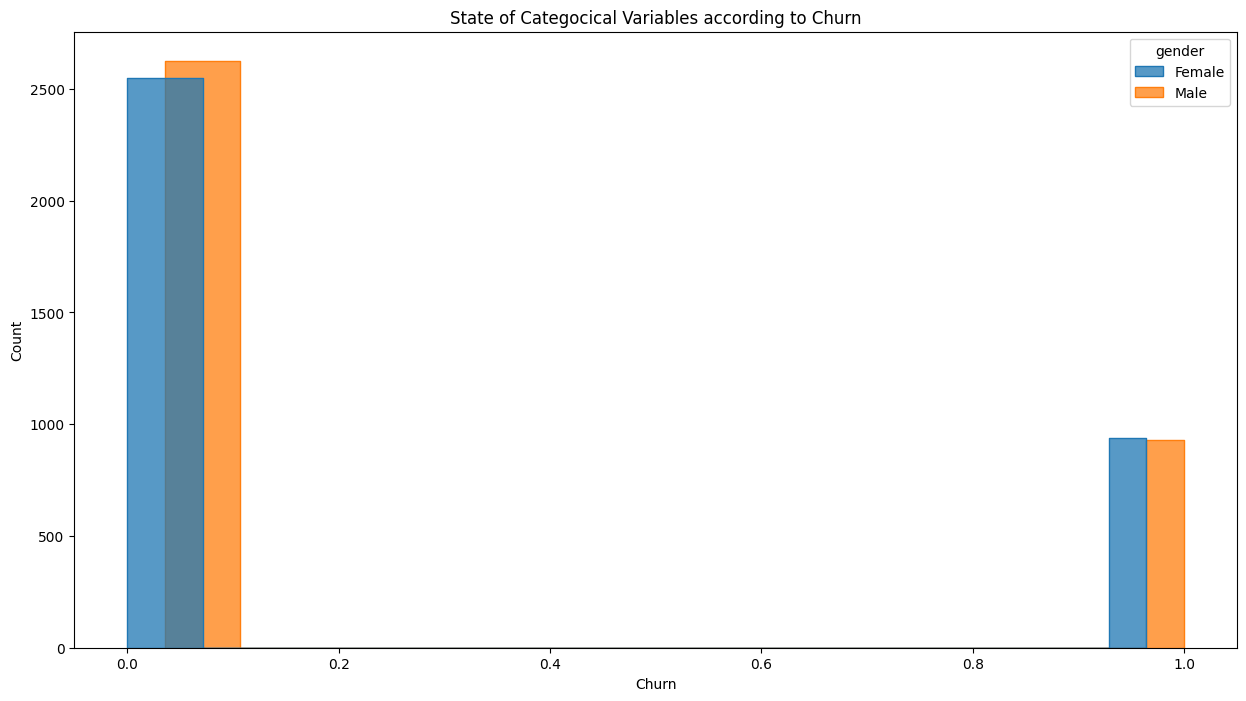

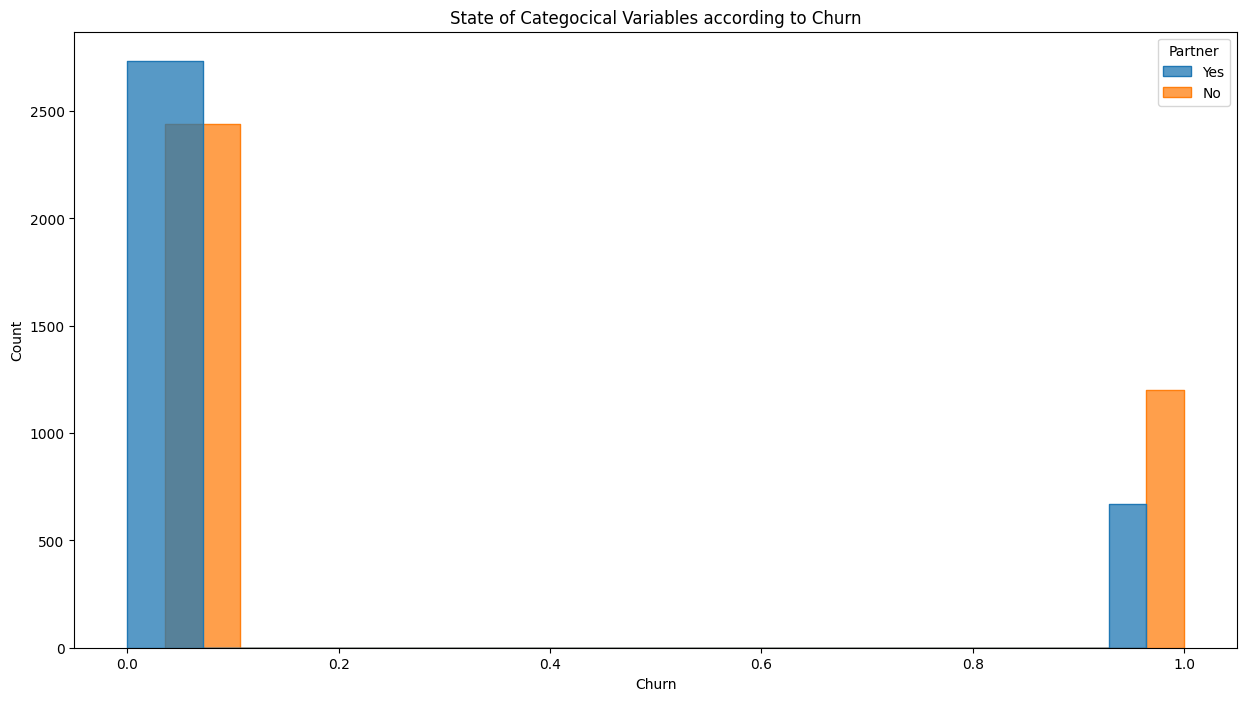

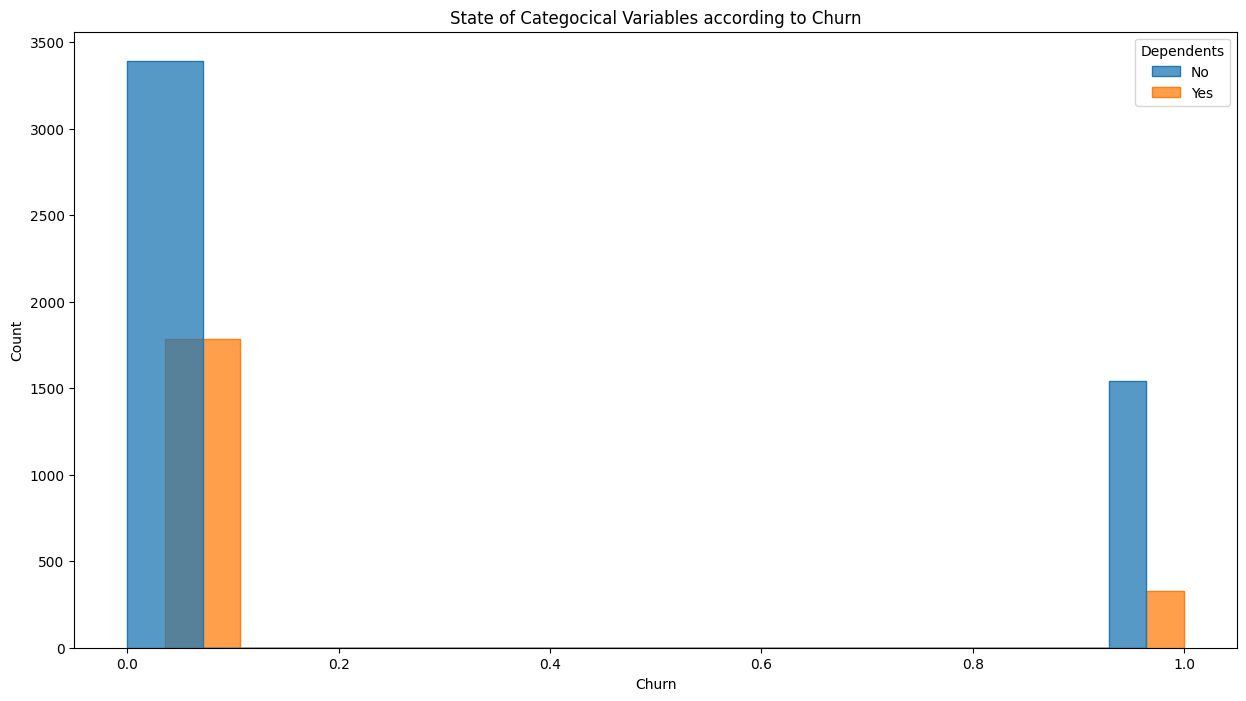

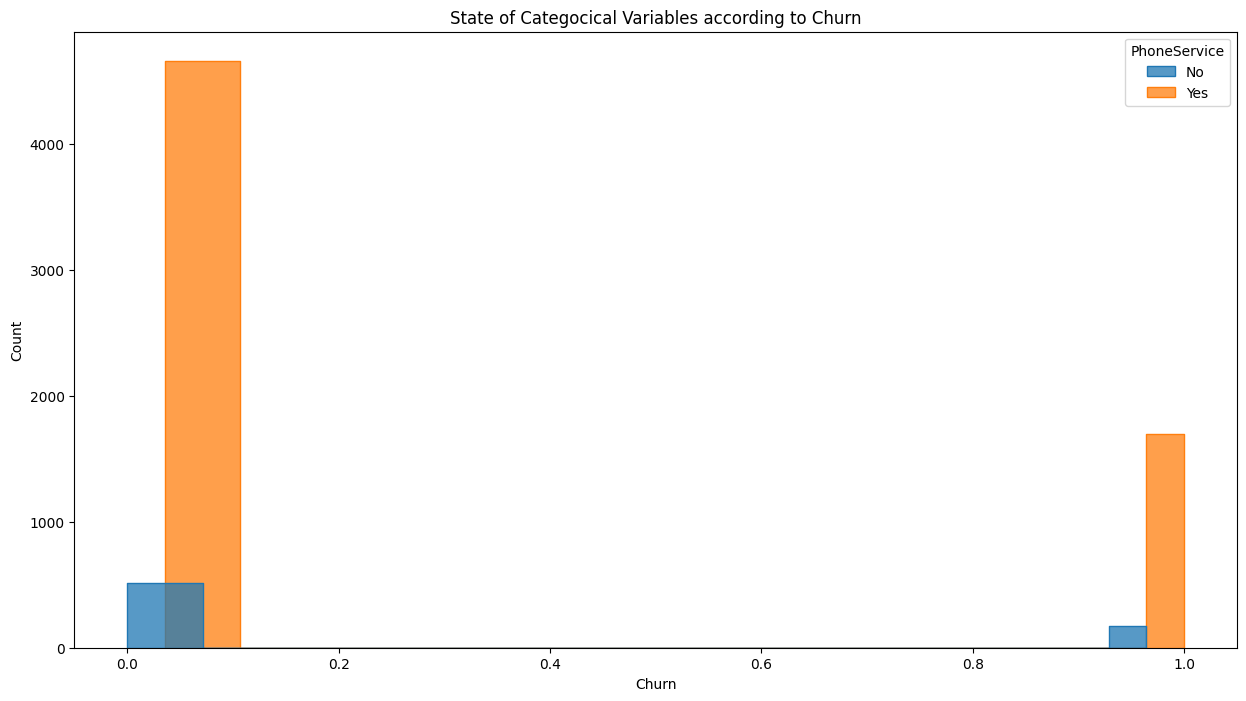

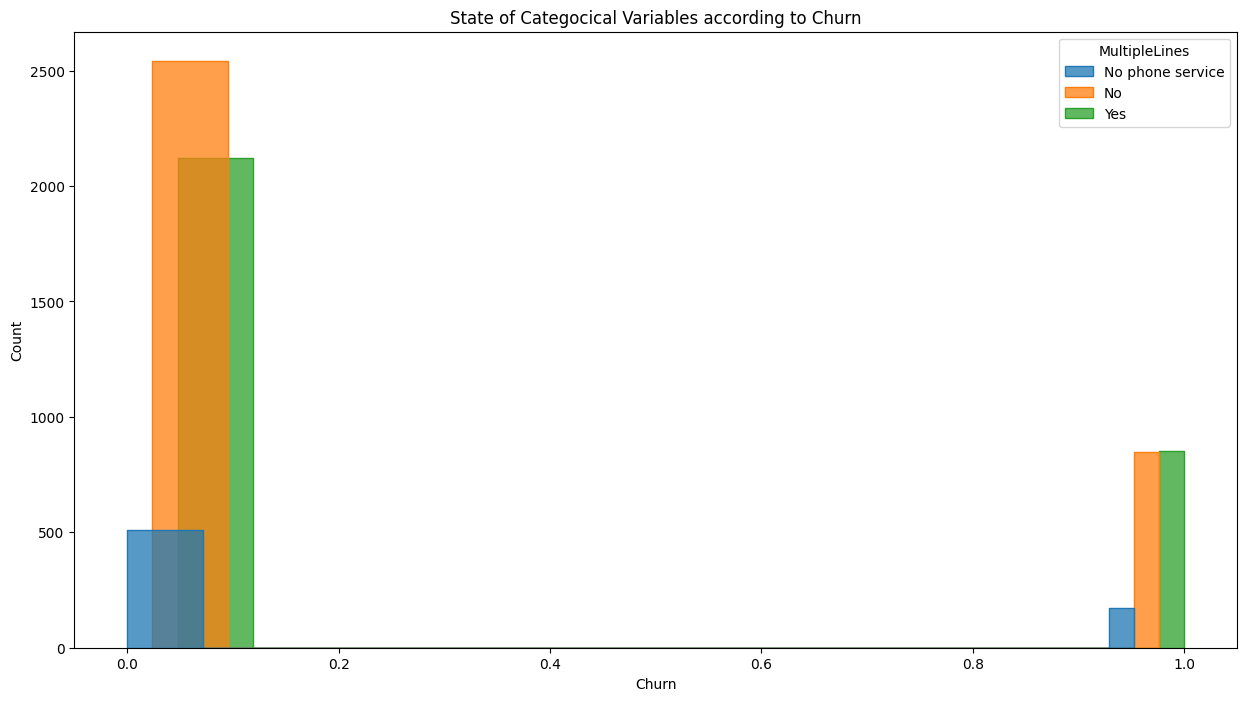

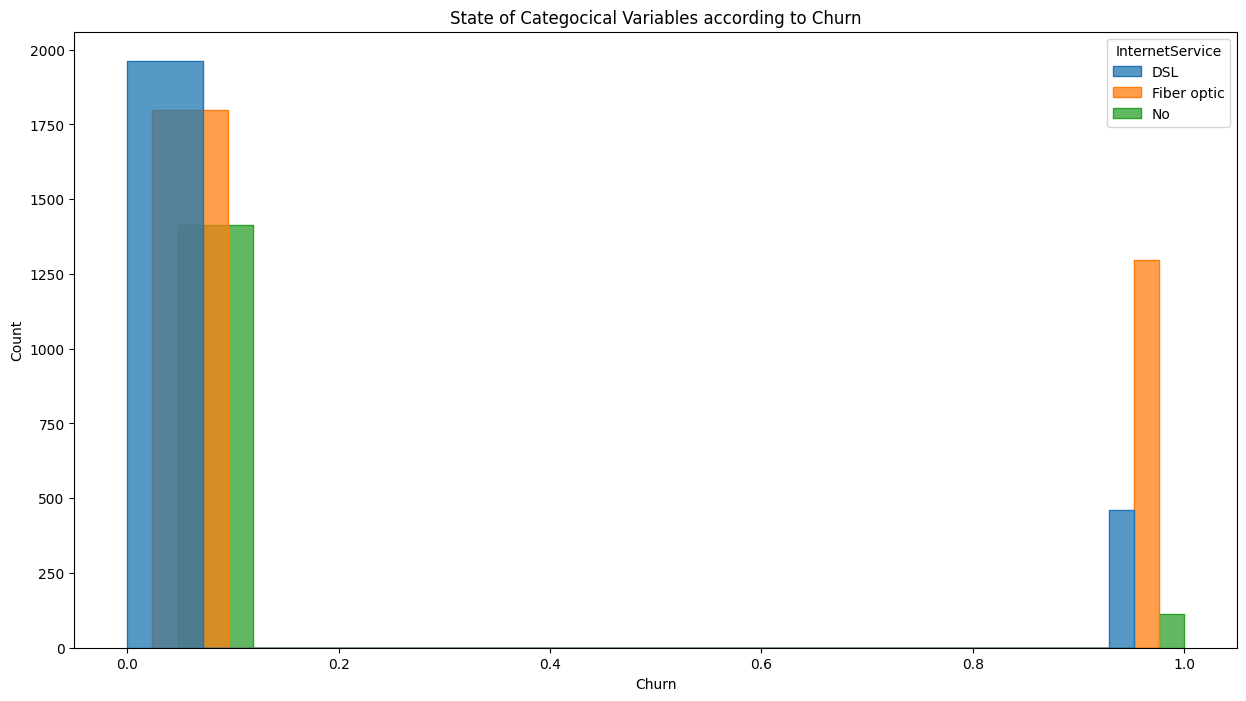

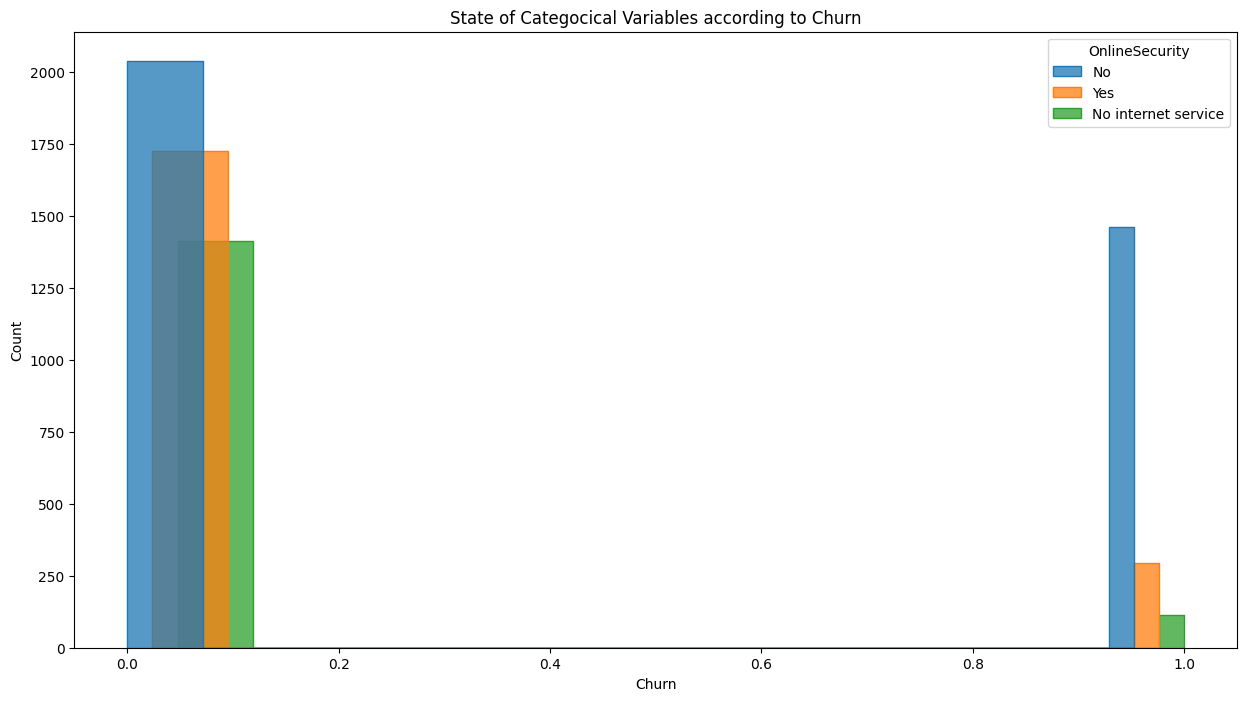

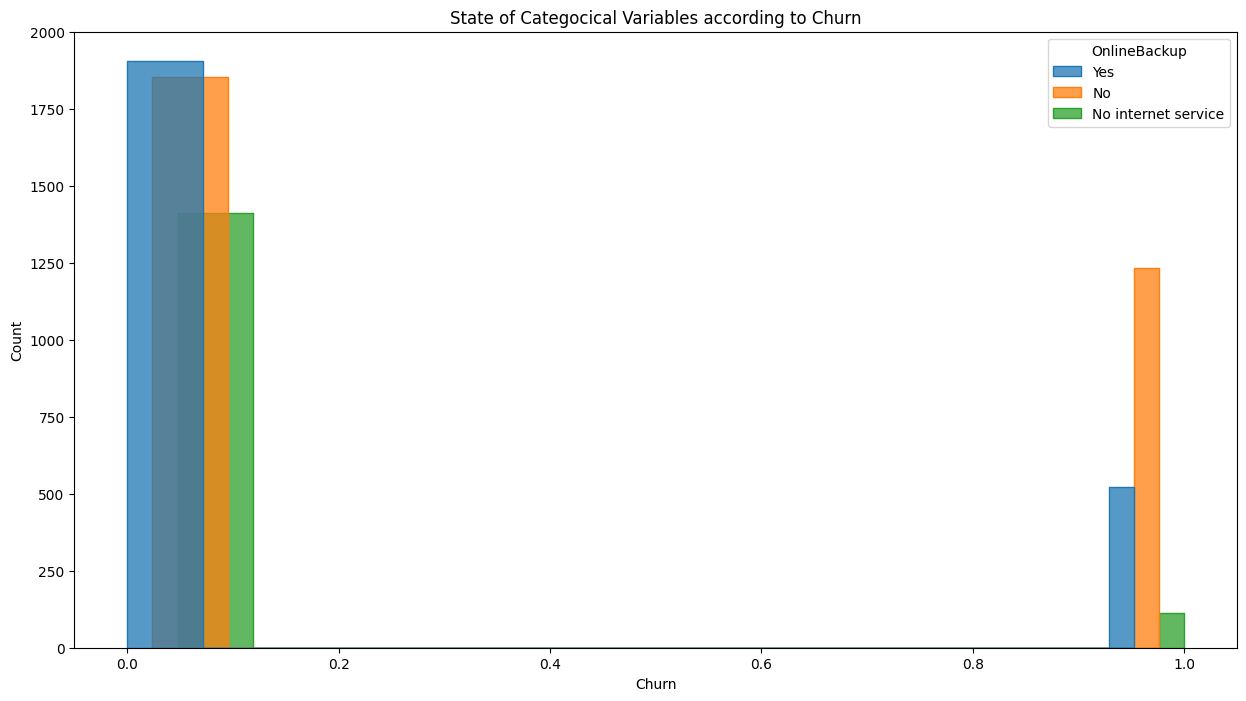

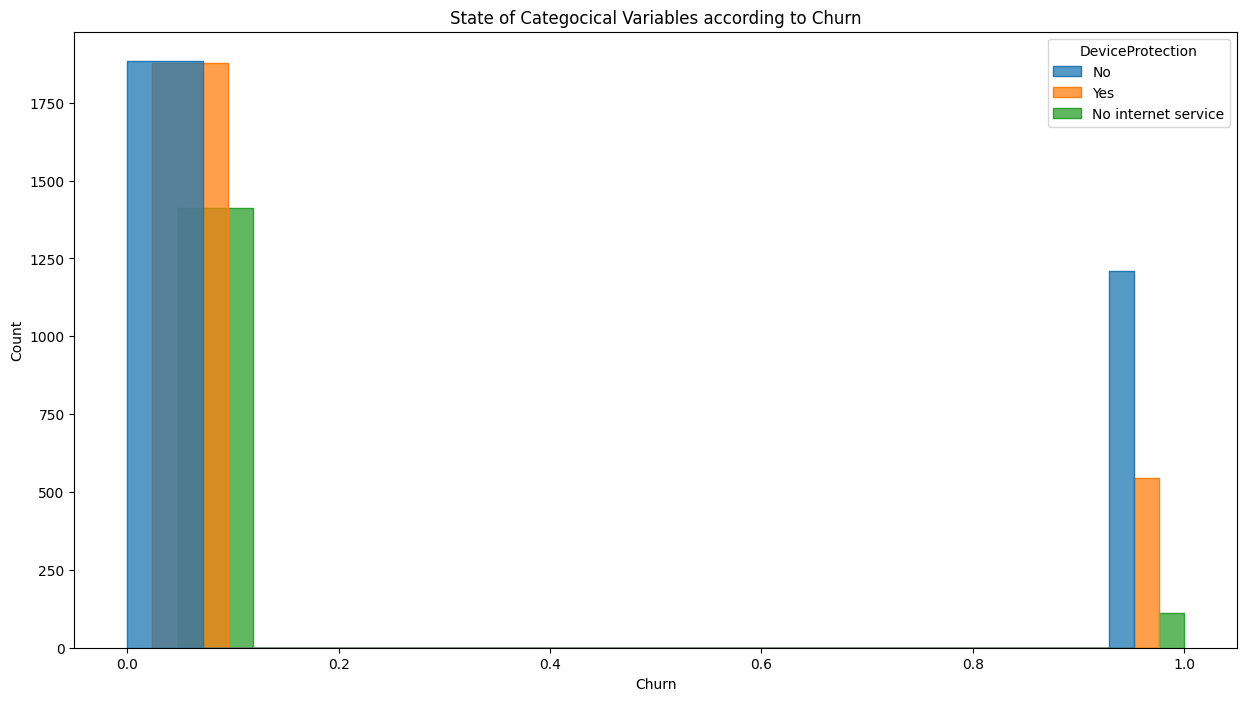

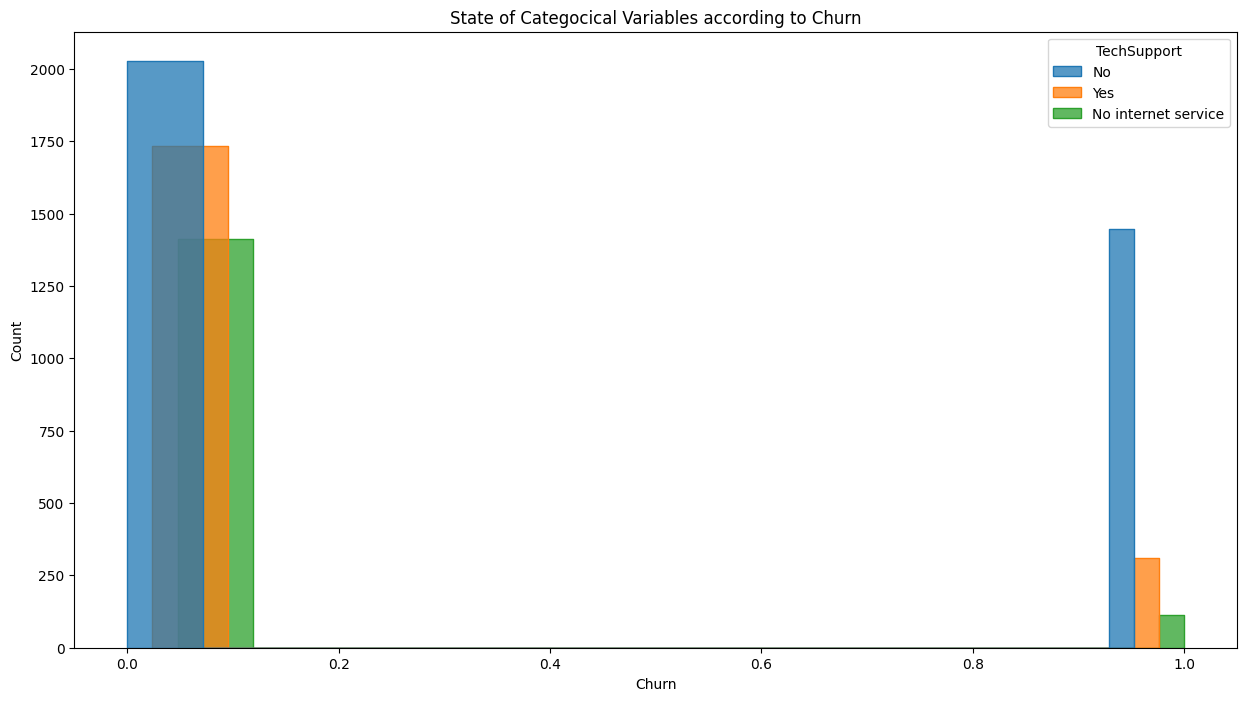

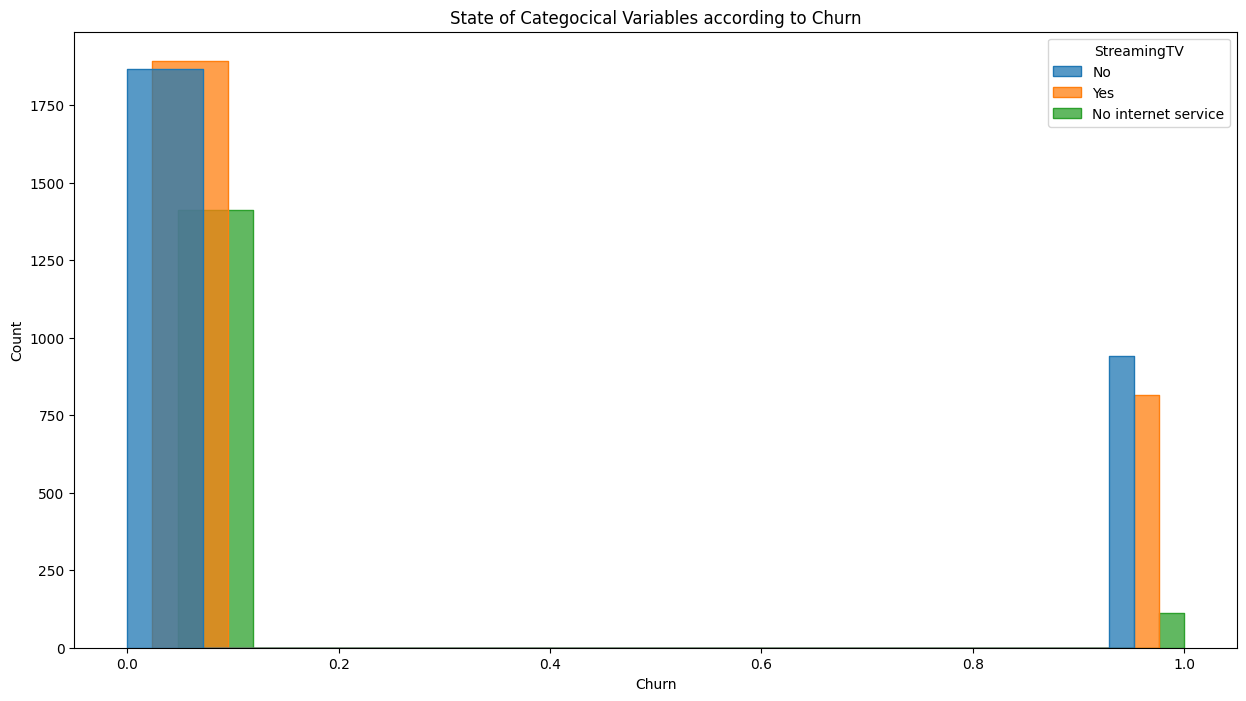

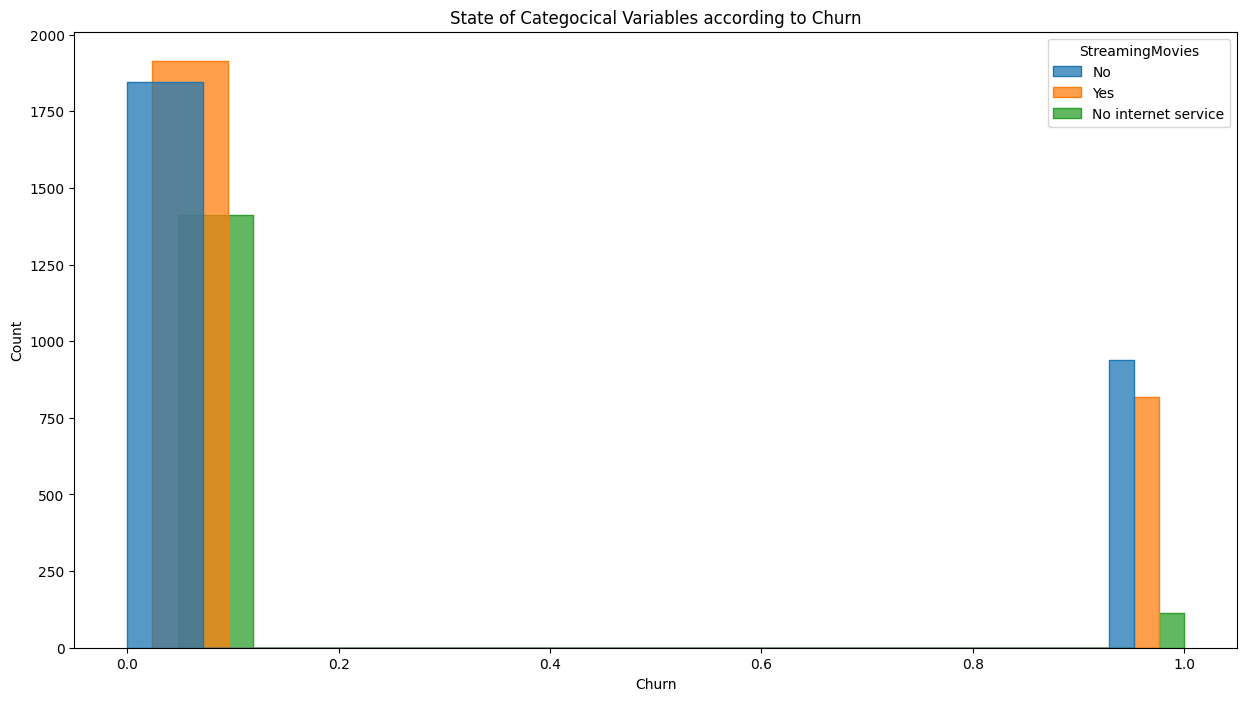

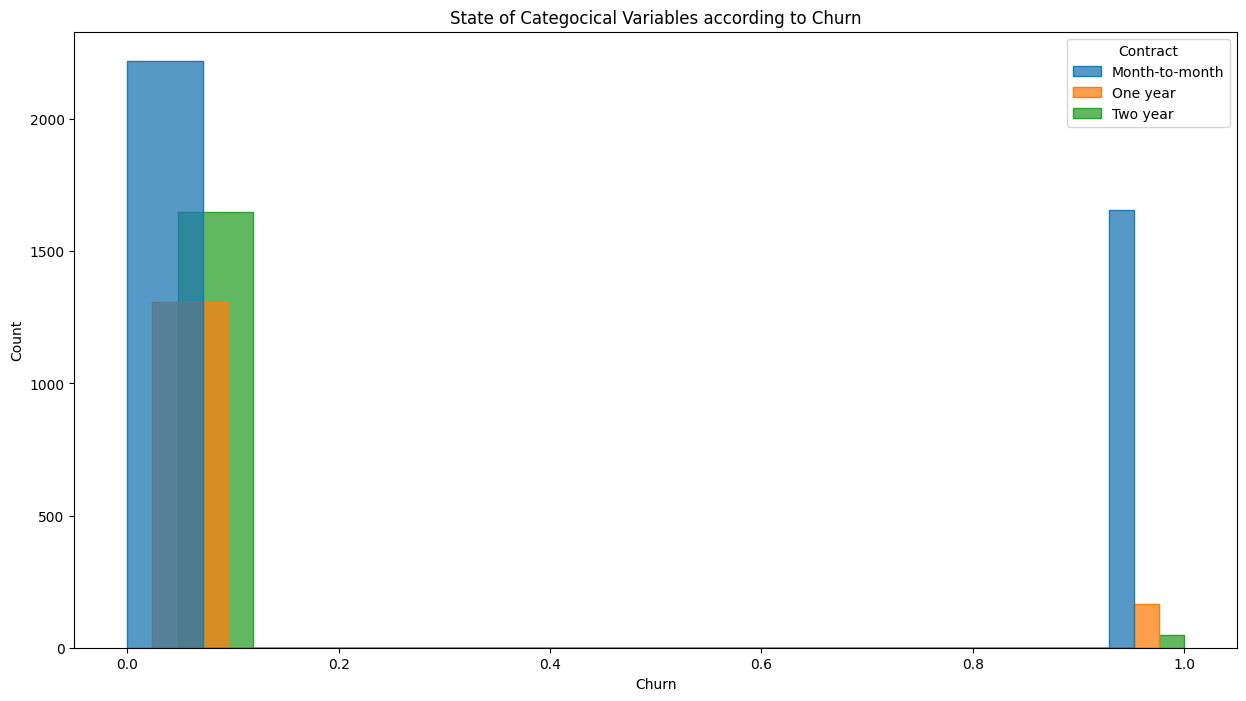

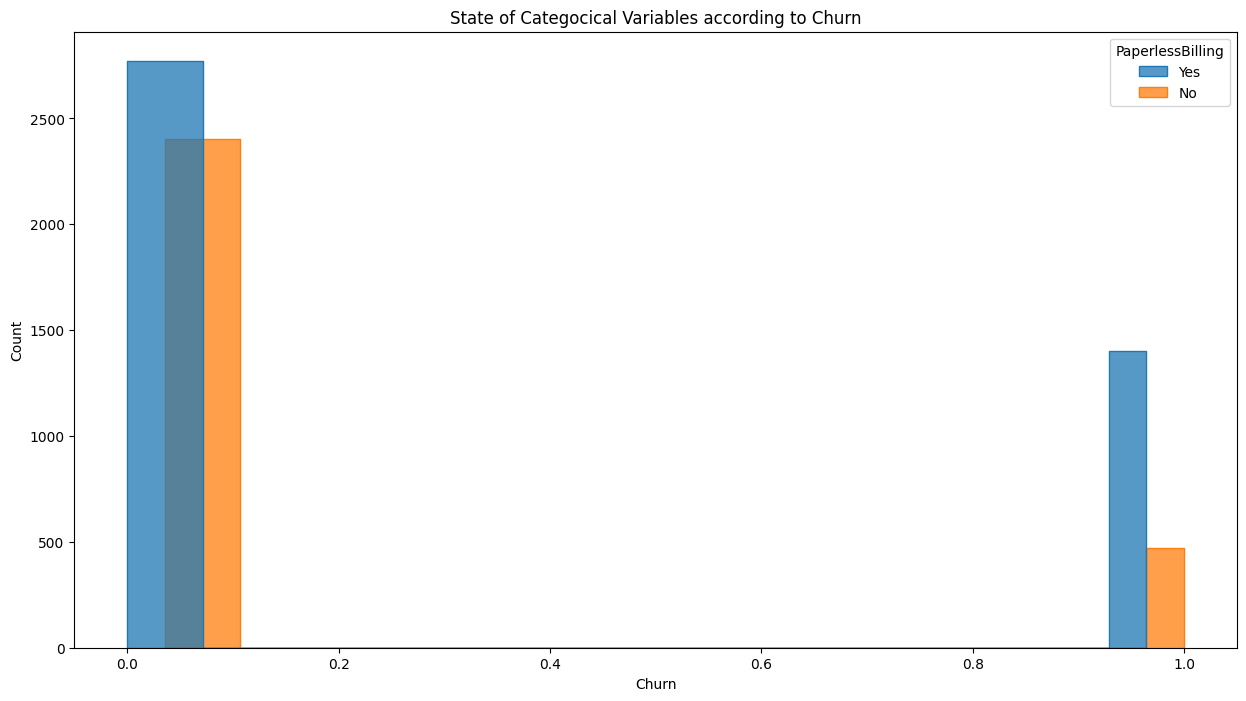

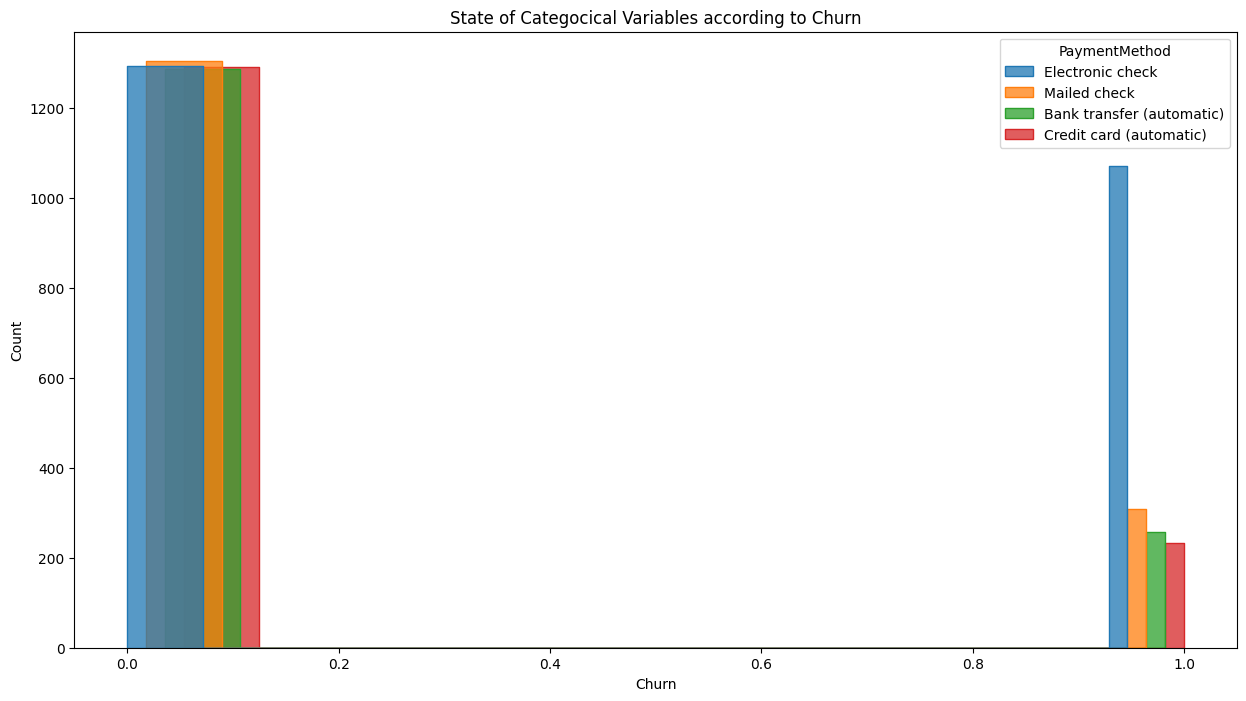

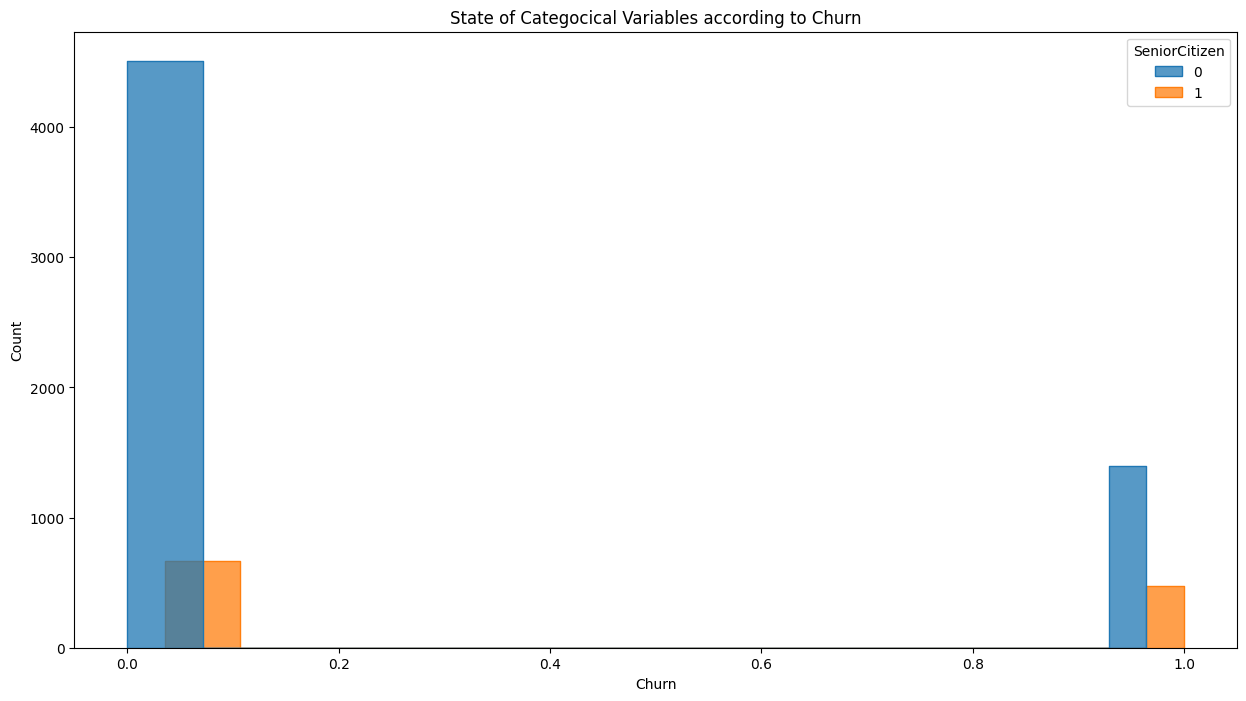

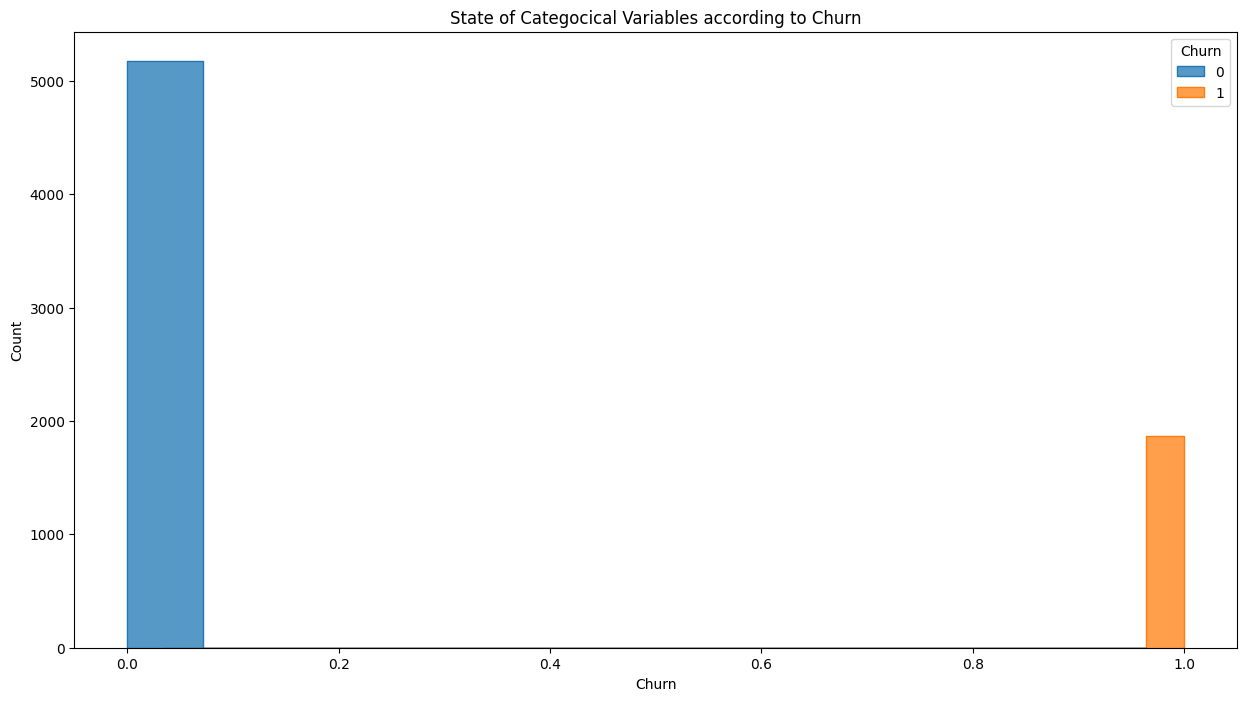

In [64]:
def target_vs_category_visual(dataframe, target, categorical_col):
  plt.figure(figsize=(15,8))
  sns.histplot(x=target, hue=categorical_col, data=dataframe, element="step", multiple="dodge")
  plt.title("State of Categocical Variables according to Churn")
  plt.show()


for col in cat_cols:
    target_vs_category_visual(df, "Churn", col)

**Performing Churn Analysis**

The mean of the numeric variables based on the Churn variable

In [65]:
def target_summary_with_num(dataframe, target, numerical_col):
  print(dataframe.groupby(target).agg({numerical_col: "mean"}), end ="\n\n")

for col in num_cols:
  target_summary_with_num(df, "Churn", col)

          tenure
Churn           
0      37.569965
1      17.979133

       MonthlyCharges
Churn                
0           61.265124
1           74.441332

       TotalCharges
Churn              
0       2555.344141
1       1531.796094



The mean of the categorical variables based on the Churn variable

In [66]:
def target_summary_with_cat(dataframe, target, categorical_col):
  print(pd.DataFrame({"Churn_mean": dataframe.groupby(categorical_col)[target].mean()}))

for col in cat_cols:
  target_summary_with_cat(df, "Churn", col)

        Churn_mean
gender            
Female    0.269209
Male      0.261603
         Churn_mean
Partner            
No         0.329580
Yes        0.196649
            Churn_mean
Dependents            
No            0.312791
Yes           0.154502
              Churn_mean
PhoneService            
No              0.249267
Yes             0.267096
                  Churn_mean
MultipleLines               
No                  0.250442
No phone service    0.249267
Yes                 0.286099
                 Churn_mean
InternetService            
DSL                0.189591
Fiber optic        0.418928
No                 0.074050
                     Churn_mean
OnlineSecurity                 
No                     0.417667
No internet service    0.074050
Yes                    0.146112
                     Churn_mean
OnlineBackup                   
No                     0.399288
No internet service    0.074050
Yes                    0.215315
                     Churn_mean
DeviceProtectio



*   There is no significant difference in the number of departures of male and female customers.
*   The churn rate of customers paying by electronic check seems high
*   Customers with monthly contracts seem to have a high churn rate.
*   It appears that customers using 'fiber optic internet' have a high churn rate.



**Looking for Outliers on numerical variables**

In [67]:
def outlier_thresholds(dataframe, col_name, q1=0.05, q3=0.95):
  quartile1 = dataframe[col_name].quantile(q1)
  quartile3 = dataframe[col_name].quantile(q3)
  interquartile_range = quartile3 - quartile1
  upper_limit = quartile3 + (1.5 * interquartile_range)
  lower_limit = quartile1 - (1.5 * interquartile_range)

  return lower_limit, upper_limit

In [68]:
def check_outlier(dataframe, col_name):
  lower_limit, upper_limit = outlier_thresholds(dataframe, col_name)

  if dataframe[(dataframe[col_name] > upper_limit) |
               (dataframe[col_name] < lower_limit)].any(axis=None):
    return True
  else:
    return False

In [69]:
def grab_outliers(dataframe, col_name, index=False):
  low, high = outlier_thresholds(dataframe, col_name)

  if dataframe[((dataframe[col_name] < low) |
                (dataframe[col_name] > high))].shape(0) > 10:
    print(dataframe[((dataframe[col_name] < low) |
                     (dataframe[col_name] > high))].head())
  else:
    print(dataframe[((dataframe[col_name] < low) |
                    (dataframe[col_name] > high))])

  if index:
      outlier_index = dataframe[((dataframe[col_name] < low) |
                                 (dataframe[col_name] > high))].index
      return outlier_index

for col in num_cols:
  print(col, check_outlier(df, col))

tenure False
MonthlyCharges False
TotalCharges False


There are no outliers within the numerical variables

**Correlation Analysis**

In [70]:
corr_matrix = df[num_cols].corr()
corr_matrix

,tenure,MonthlyCharges,TotalCharges
tenure,1.00000,0.247900,0.825880
MonthlyCharges,0.24790,1.000000,0.651065
TotalCharges,0.82588,0.651065,1.000000


In [71]:
df.select_dtypes(include=np.number).corrwith(df["Churn"]).sort_values(ascending=False)

,0
Churn,1.000000
MonthlyCharges,0.193356
SeniorCitizen,0.150889
TotalCharges,-0.199484
tenure,-0.352229


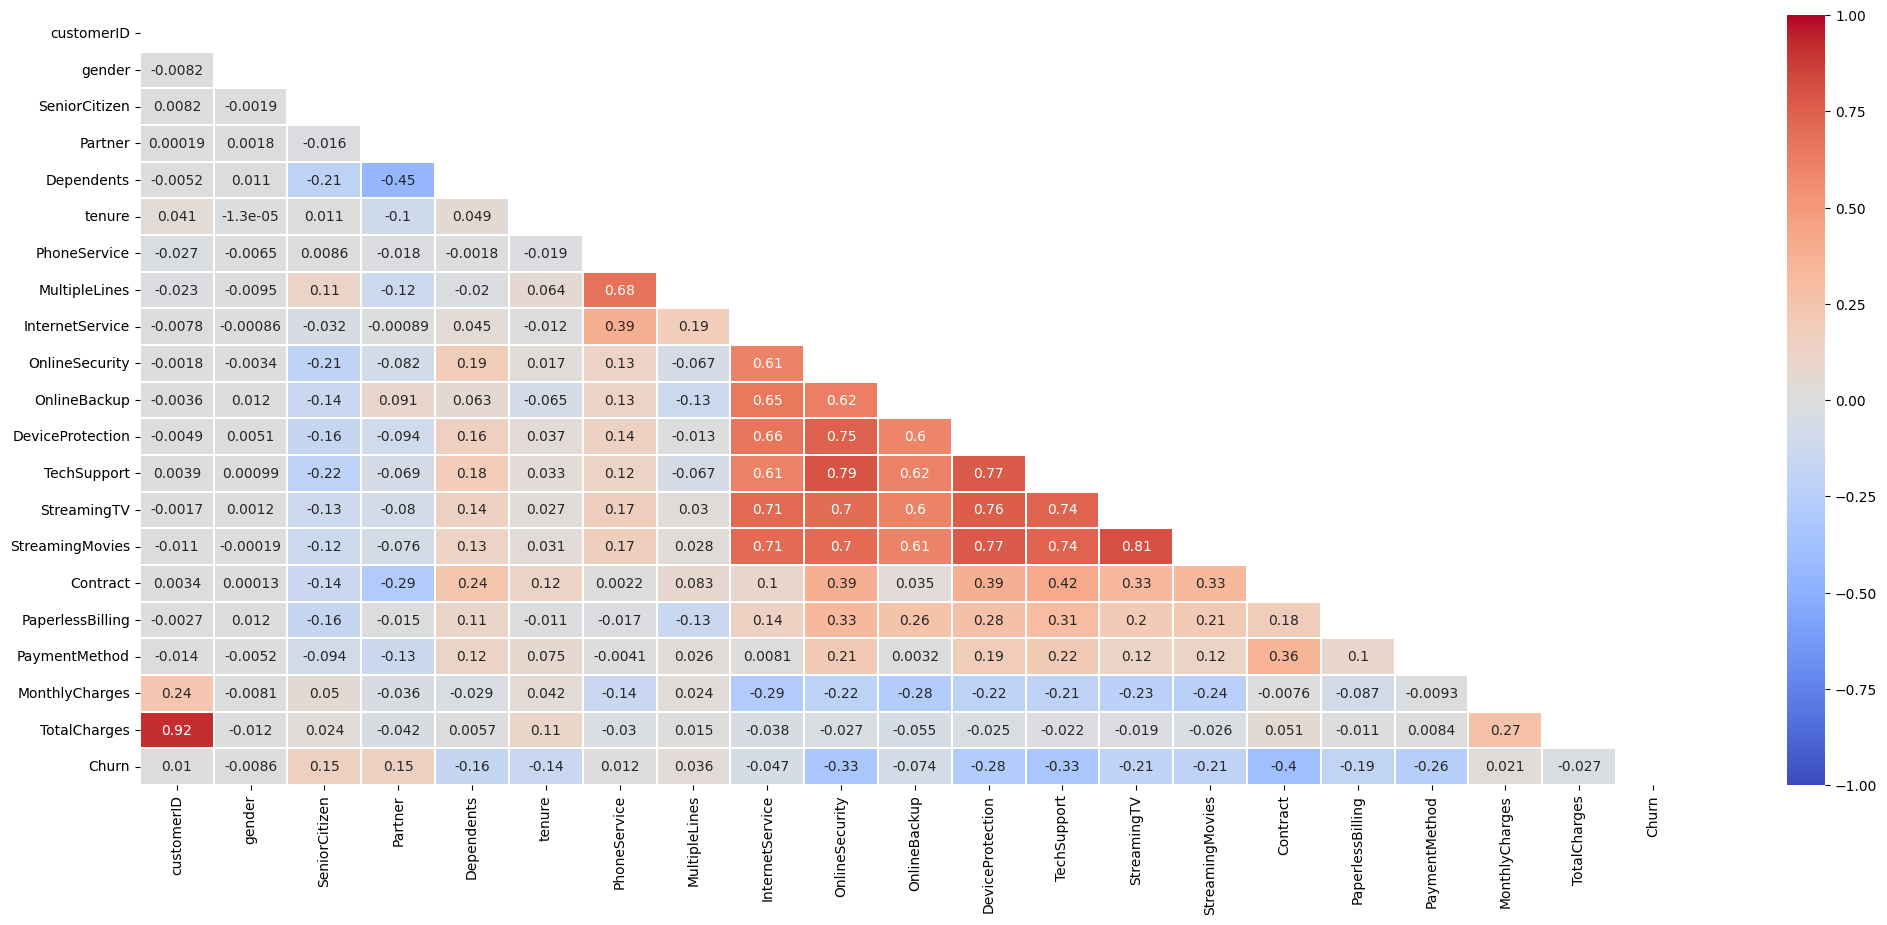

In [72]:
# Correlation between all variables
plt.figure(5, figsize=(25, 10))
corr = df.apply(lambda x: pd.factorize(x)[0]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
ax = sns.heatmap(corr, mask=mask, xticklabels=corr.columns, yticklabels=corr.columns, annot=True, linewidths=0.2, cmap='coolwarm', vmin=-1, vmax=1)



*   There is a positive correlation between churn and the age of customers. Most Senior citizens churn.
    *   Maybe there is some campaign by competitors that are targeting senior citizens.
*   Logically, longer tenure means more loyalty which results in less churn risk.
*   Logically, higher monthly charges and higher total charges can result in greater churn risk.
*   Interestingly, it appears that total charges have a negative correlation to churn.



**Missing Value Analysis**

In [73]:
def missing_values_table(dataframe, na_name=False):
  na_columns = [
      col for col in dataframe.columns
        if dataframe[col].isnull().sum() > 0
  ]

  num_missing = dataframe[na_columns].isnull().sum().sort_values(ascending=False)

  ratio = (dataframe[na_columns].isnull().sum() / dataframe.shape[0] * 100).sort_values(ascending=False)

  missing_df = pd.concat([num_missing, np.round(ratio, 2)], axis=1, keys=['num_missing', 'ratio'])

  print(missing_df, end="\n")


  if na_name:
    return na_columns



missing_values_table(df)

              num_missing  ratio
TotalCharges           11   0.16


**Filling in missing values with mean for TotalCharges**

In [74]:
df[df["TotalCharges"].isnull()][["tenure", "MonthlyCharges", "TotalCharges"]]
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [75]:
df["TotalCharges"].isnull().sum()

np.int64(0)

**Conclusion**

Proper churn management can save a huge amount of money for the company.
*   Satisfied customers can bring in new customers
*   Long-term customers usually do not get influenced much by competitors
*   Long-term customers tend to buy more
*   The company can focus on satisfying existing customer's needs
*   Customers who had left share negative reviews and will have a negative influence on the company

It appears that customer retention of price, customer satisfaction, and service quality could lead to better customer loyalty.

In [76]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, classification_report)

# One-hot encode categorical columns (drop_first avoids multicollinearity)
model_df = pd.get_dummies(df.drop(columns=["customerID"]), drop_first=True)

X = model_df.drop(columns=["Churn"])
y = model_df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale numeric features (helps logistic regression converge/perform better)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Because of class imbalance (~73/27), use class_weight='balanced'
model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:   ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))
print("ROC-AUC:  ", roc_auc_score(y_test, y_proba))
print("\n", classification_report(y_test, y_pred))

Accuracy:  0.7402413058907026
Precision: 0.506896551724138
Recall:    0.786096256684492
F1 Score:  0.6163522012578616
ROC-AUC:   0.8414012245214291

               precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



**Confusion Matrix**

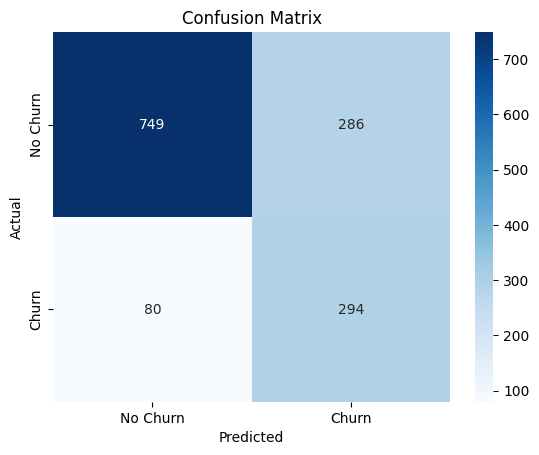

In [78]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Limitations & Next Steps

**Data:**
- 11 missing TotalCharges values (0.16% of rows) were imputed with the
  column mean rather than dropped or set to 0. This is a reasonable default
  but wasn't validated against whether those rows share a specific pattern
  (e.g., new customers); this should be checked before treating the
  imputation as fully justified.
- Outlier detection used 5th/95th percentile IQR bounds rather than the
  conventional 25th/75th — a more lenient threshold. "No outliers found"
  should be read in that context, not as evidence under a standard IQR test.
- The full correlation heatmap used `pd.factorize()` on all columns,
  including numeric ones. Factorizing reassigns values based on order of
  first appearance rather than preserving numeric magnitude, which distorts
  correlation for already-numeric columns (tenure, MonthlyCharges,
  TotalCharges) — not just nominal ones. The clean numeric-only correlation
  matrix (tenure–TotalCharges = 0.826) is the trustworthy version; the
  factorized customerID–TotalCharges = 0.92 correlation is a known artifact
  of factorizing a near-unique ID column and carries no real-world meaning.

**Model:**
- Precision on the churn class is modest (0.51) — about half of customers
  flagged as "at risk" would not have actually churned. Any retention
  campaign built on this model should budget for that false-positive rate.
- Logistic regression assumes a linear relationship between features and
  log-odds of churn, and may miss non-linear interactions between features
  (e.g., contract type combined with tenure).
- Only one model architecture was tested; no hyperparameter tuning or
  cross-validation was performed beyond a single train/test split.
- The dataset is a single time snapshot; churn drivers may shift with
  seasonality, pricing changes, or competitor activity not captured here.

**Next Steps:**
- Verify whether the 11 missing TotalCharges rows share a common trait
  (e.g., tenure = 0) before finalizing the imputation approach.
- Try tree-based models (Random Forest, XGBoost) to test for non-linear
  gains over the logistic regression baseline, using the same stratified
  split and class-balancing approach for a fair comparison.
- Tune the classification threshold based on the real-world cost of a
  missed churner vs. an unnecessary retention offer, rather than the
  default 0.5 cutoff.
- Add cross-validation to get a more robust estimate of model performance
  than a single train/test split provides.
- Engineer features such as total services subscribed or average spend
  per tenure month.